**Set-Up Ambiente**

In [1]:
import subprocess
subprocess.run(["pip", "install", "-q", "--force-reinstall", "opencv-python-headless==4.9.0.80"])

CompletedProcess(args=['pip', 'install', '-q', '--force-reinstall', 'opencv-python-headless==4.9.0.80'], returncode=0)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -r /content/drive/MyDrive/FAIML-RL-26/requirements.txt -q

%cd /content/drive/MyDrive/FAIML-RL-26/part2/panda-gym
!pip install -e .

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/FAIML-RL-26/part2/panda-gym
Obtaining file:///content/drive/MyDrive/FAIML-RL-26/part2/panda-gym
  Preparing metadata (setup.py) ... done
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.6
    Uninstalling numpy-2.4.6:
      Successfully uninstalled numpy-2.4.6
  Attempting uninstall: panda_gym
    Found existing installation: panda_gym 3.0.8
    Uninstalling panda_gym-3.0.8:
      Successfully uninstalled panda_gym-3.0.8
  Running setup.py develop for panda_gym
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following depend

**Import necessari**

In [3]:
import argparse
import os

import gymnasium as gym
import numpy as np
from stable_baselines3 import SAC
import panda_gym  # noqa: F401 - required so Panda envs are registered
import json
import matplotlib.pyplot as plt

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**Evaluate**

In [11]:
def evaluate(model_path: str, n_episodes: int, deterministic: bool, render: bool, env_type: str, env_training: str) -> None:
    if not os.path.exists(model_path):
        raise FileNotFoundError(
            f"Model file not found: {model_path}. "
            "Make sure you saved your trained model with model.save(...)."
        )

    render_mode = "human" if render else "rgb_array"
    env = gym.make("PandaPush-v3", render_mode=render_mode, type=env_type, reward_type="dense")
    #TODO: load model here
    model = SAC.load(model_path)

    episode_returns = []
    successes = []

    for episode in range(1, n_episodes + 1):
        obs, info = env.reset(seed=42 + episode)
        terminated = False
        truncated = False
        episode_return = 0.0

        while not (terminated or truncated):
            action,_ = model.predict(obs, deterministic=deterministic) #TODO: get action from the model
            obs, reward, terminated, truncated, info = env.step(action)
            episode_return += float(reward)

        episode_returns.append(episode_return)

        if isinstance(info, dict) and "is_success" in info:
            successes.append(float(info["is_success"]))

        print(f"Episode {episode:03d} | return = {episode_return:.3f}")

    env.close()

    returns = np.array(episode_returns, dtype=np.float32)
    print("\n=== Evaluation summary ===")
    print(f"Episodes: {n_episodes}")
    print(f"Mean return: {returns.mean():.3f}")
    print(f"Std return:  {returns.std():.3f}")
    print(f"Min return:  {returns.min():.3f}")
    print(f"Max return:  {returns.max():.3f}")

    if successes:
        success_rate = float(np.mean(successes))
        print(f"Success rate: {success_rate:.2%}")

    #Aggiunta
    results = {
      "model": model_path,
      "env_type": env_type,
      "n_episodes": n_episodes,
      "mean_return": float(returns.mean()),
      "std_return": float(returns.std()),
      "min_return": float(returns.min()),
      "max_return": float(returns.max()),
      "success_rate": float(np.mean(successes)) if successes else None
    }
    with open(f"/content/drive/MyDrive/FAIML-RL-26/results/eval_{env_training}_model/eval_{env_type}.json", "w") as f:
        json.dump(results, f, indent=2)

    plt.figure(figsize=(8, 4))
    plt.hist(episode_returns, bins=20, color='#534AB7', edgecolor='white')
    plt.axvline(returns.mean(), color='red', linestyle='--', label=f'Mean: {returns.mean():.2f}')
    plt.xlabel('Episode return')
    plt.ylabel('Count')
    plt.title(f'Return distribution — Evaluation on {env_type} - Training on {env_training}')
    plt.legend()
    plt.savefig(f"/content/drive/MyDrive/FAIML-RL-26/results/eval_{env_training}_model/eval_{env_type}.png", dpi=150)
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(range(1, n_episodes + 1), episode_returns, color='#534AB7', linewidth=1.5)
    plt.axhline(returns.mean(), color='red', linestyle='--', label=f'Mean: {returns.mean():.2f}')
    plt.xlabel('Episode')
    plt.ylabel('Return')
    plt.title(f'Return per episode — Evaluation on {env_type} - Training on {env_training}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(f"/content/drive/MyDrive/FAIML-RL-26/results/eval_{env_training}_model/eval_{env_type}_per_episode.png", dpi=150)
    plt.show()

    cumulative_success = np.cumsum(successes) / np.arange(1, len(successes) + 1)

    plt.figure(figsize=(10, 4))
    plt.plot(range(1, len(successes) + 1), cumulative_success, color='#0F6E56', linewidth=1.5)
    plt.axhline(np.mean(successes), color='red', linestyle='--', label=f'Final: {np.mean(successes):.2%}')
    plt.xlabel('Episode')
    plt.ylabel('Cumulative success rate')
    plt.title(f'Cumulative success rate — Evaluation on {env_type} - Training on {env_training}')
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(f"/content/drive/MyDrive/FAIML-RL-26/results/eval_{env_training}_model/eval_{env_type}_success_rate.png", dpi=150)
    plt.show()

**Parse_args (non mi serve)**

In [7]:
def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(description="Evaluate SAC on PandaPush-v3")
    parser.add_argument(
        "--model-path",
        type=str,
        required=True,
        help="Path to a PPO model zip file (e.g., ppo_panda_push.zip)",
    )
    parser.add_argument(
        "--episodes",
        type=int,
        default=500,
        help="Number of eval episodes"
    )
    parser.add_argument(
        "--stochastic",
        action="store_true",
        help="Use stochastic policy sampling instead of deterministic actions",
    )
    parser.add_argument(
        "--render",
        action="store_true",
        help="Render with a window (render_mode='human')",
    )
    parser.add_argument(
        "--env-type",
        type=str, default="target",
        choices=["source", "target"],
        help="Type of environment to evaluate on (default: target)",
    )
    return parser.parse_args()

**Main source-source**

Created object with mass: 1.0
Episode 001 | return = -3.920
Episode 002 | return = -1.099
Episode 003 | return = -0.016
Episode 004 | return = -0.942
Episode 005 | return = -0.515
Episode 006 | return = -0.030
Episode 007 | return = -0.033
Episode 008 | return = -0.713
Episode 009 | return = -1.667
Episode 010 | return = -0.028
Episode 011 | return = -1.560
Episode 012 | return = -0.534
Episode 013 | return = -0.886
Episode 014 | return = -0.628
Episode 015 | return = -0.037
Episode 016 | return = -2.078
Episode 017 | return = -0.372
Episode 018 | return = -1.396
Episode 019 | return = -3.060
Episode 020 | return = -0.784
Episode 021 | return = -4.961
Episode 022 | return = -0.487
Episode 023 | return = -4.530
Episode 024 | return = -0.748
Episode 025 | return = -0.837
Episode 026 | return = -0.398
Episode 027 | return = -0.017
Episode 028 | return = -0.454
Episode 029 | return = -0.050
Episode 030 | return = -0.888
Episode 031 | return = -0.039
Episode 032 | return = -0.422
Episode 03

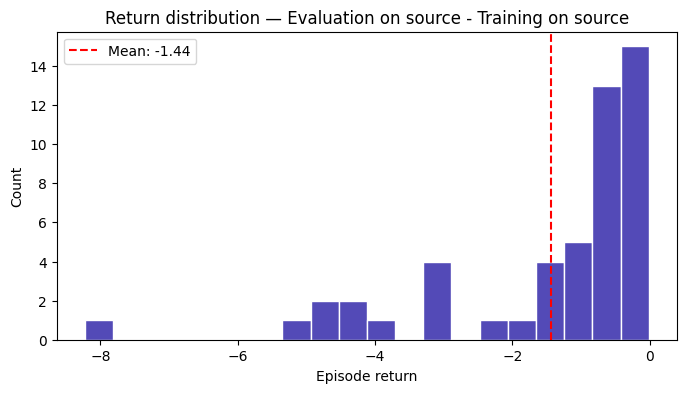

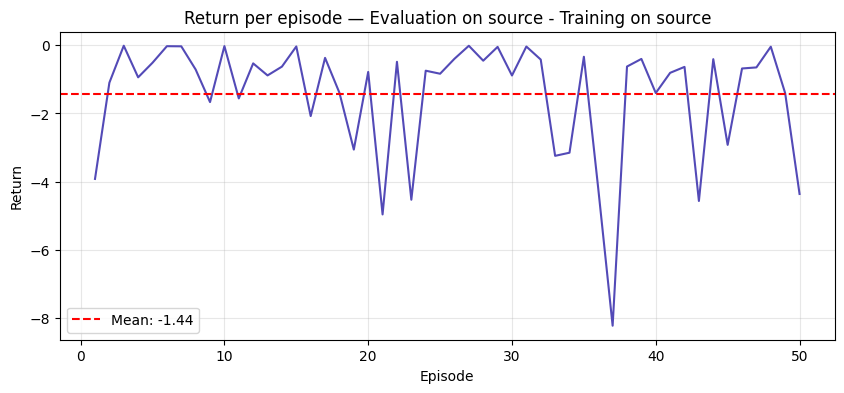

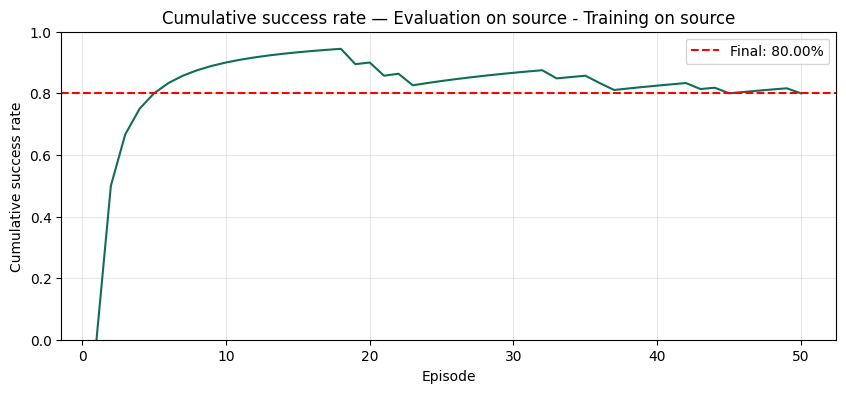

In [12]:
if __name__ == "__main__":
    #args = parse_args()
    evaluate(
        model_path="/content/drive/MyDrive/FAIML-RL-26/results/sac_source/sac_push_none_source_500000_batchsize.zip", #args.model_path,
        n_episodes=50, #args.episodes,
        deterministic= True, #not args.stochastic,
        render=False, #args.render,
        env_type="source", #args.env_type,
        env_training = "source",
    )

**Main source-target**

Created object with mass: 5.0
Episode 001 | return = -4.118
Episode 002 | return = -1.170
Episode 003 | return = -0.016
Episode 004 | return = -1.941
Episode 005 | return = -0.525
Episode 006 | return = -0.030
Episode 007 | return = -0.033
Episode 008 | return = -0.689
Episode 009 | return = -3.902
Episode 010 | return = -0.028
Episode 011 | return = -1.593
Episode 012 | return = -0.541
Episode 013 | return = -1.005
Episode 014 | return = -0.725
Episode 015 | return = -0.037
Episode 016 | return = -1.198
Episode 017 | return = -2.538
Episode 018 | return = -1.438
Episode 019 | return = -0.880
Episode 020 | return = -0.806
Episode 021 | return = -4.898
Episode 022 | return = -0.540
Episode 023 | return = -4.528
Episode 024 | return = -0.767
Episode 025 | return = -0.866
Episode 026 | return = -0.696
Episode 027 | return = -0.017
Episode 028 | return = -0.502
Episode 029 | return = -0.050
Episode 030 | return = -1.171
Episode 031 | return = -0.039
Episode 032 | return = -0.442
Episode 03

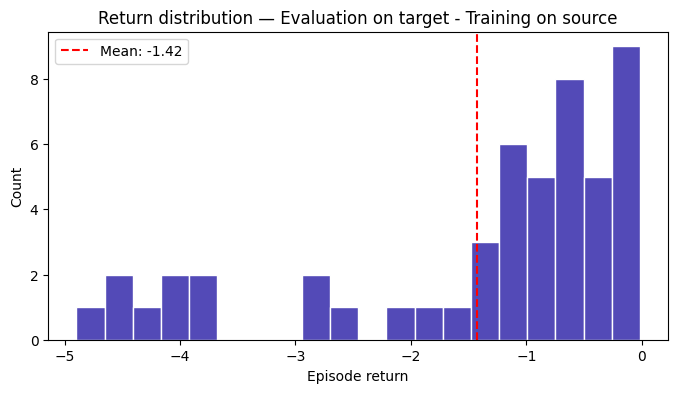

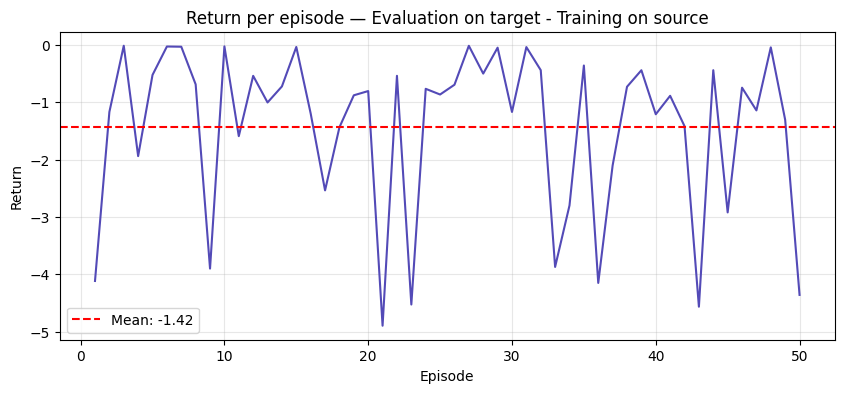

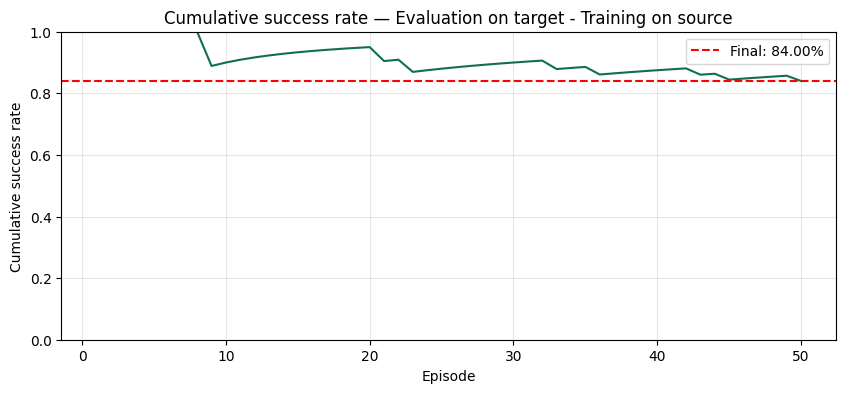

In [13]:
if __name__ == "__main__":
    #args = parse_args()
    evaluate(
        model_path="/content/drive/MyDrive/FAIML-RL-26/results/sac_source/sac_push_none_source_500000_batchsize.zip", #args.model_path,
        n_episodes=50, #args.episodes,
        deterministic= True, #not args.stochastic,
        render=False, #args.render,
        env_type="target", #args.env_type,
        env_training = "source",
    )

**Main target-target**

Created object with mass: 5.0
Episode 001 | return = -0.696
Episode 002 | return = -0.649
Episode 003 | return = -0.016
Episode 004 | return = -1.669
Episode 005 | return = -0.316
Episode 006 | return = -0.030
Episode 007 | return = -0.033
Episode 008 | return = -0.449
Episode 009 | return = -0.551
Episode 010 | return = -0.028
Episode 011 | return = -1.036
Episode 012 | return = -0.372
Episode 013 | return = -0.572
Episode 014 | return = -0.979
Episode 015 | return = -0.037
Episode 016 | return = -0.509
Episode 017 | return = -0.362
Episode 018 | return = -0.802
Episode 019 | return = -0.284
Episode 020 | return = -0.256
Episode 021 | return = -0.694
Episode 022 | return = -0.465
Episode 023 | return = -0.754
Episode 024 | return = -0.539
Episode 025 | return = -0.610
Episode 026 | return = -0.396
Episode 027 | return = -0.017
Episode 028 | return = -0.201
Episode 029 | return = -0.050
Episode 030 | return = -1.014
Episode 031 | return = -0.039
Episode 032 | return = -0.426
Episode 03

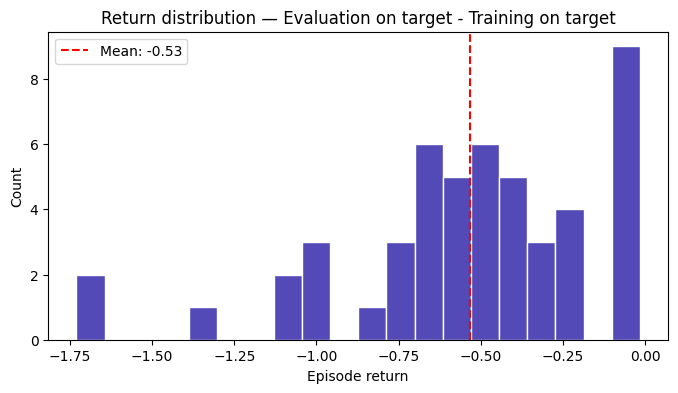

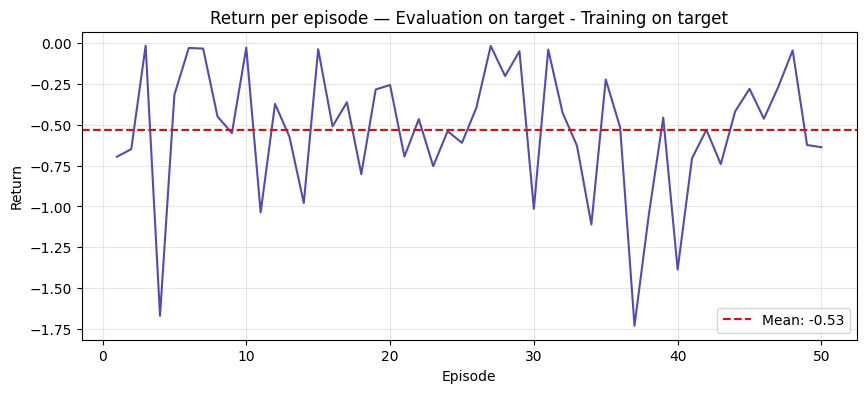

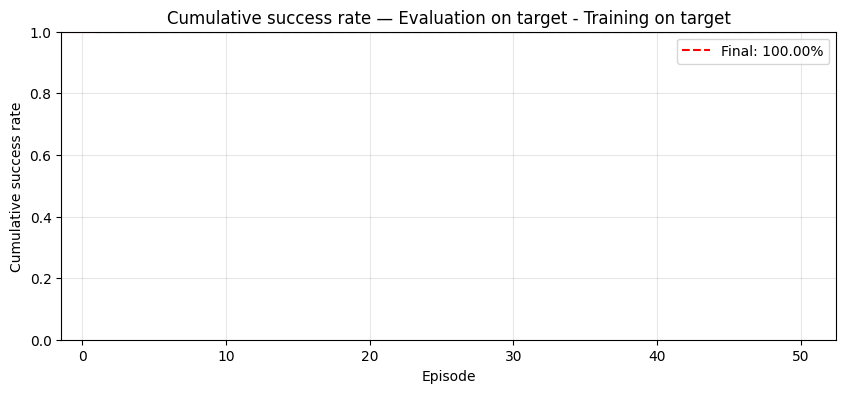

In [14]:
if __name__ == "__main__":
    #args = parse_args()
    evaluate(
        model_path="/content/drive/MyDrive/FAIML-RL-26/results/sac_target/sac_push_none_target_500000.zip", #args.model_path,
        n_episodes=50, #args.episodes,
        deterministic= True, #not args.stochastic,
        render=False, #args.render,
        env_type="target", #args.env_type,
        env_training = "target",
    )